In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import blimpy as bl 
import glob
%matplotlib inline

18359.238
1891.1299


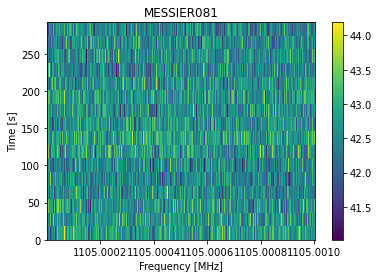

In [70]:
f = 1105

h5 = '/datax/scratch/benjb/bliss_LSCX_test/power_law/L/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000.h5'

fb = bl.Waterfall(h5, f, f+0.001)
fb.plot_waterfall()

print(np.mean(fb.data))
print(np.std(fb.data))

In [21]:
print(fb.header['tsamp'])

18.253611007999982


In [64]:
from astropy.stats import sigma_clip
clipped_data = sigma_clip(fb.data,
                                  sigma=3,
                                  maxiters=5,
                                  masked=False)
noise_std = np.std(clipped_data)

In [24]:
print(noise_std)

1850.772


18333.816
1850.7721
462693.0236816406
0
1105.0002
1105.0002
1.0


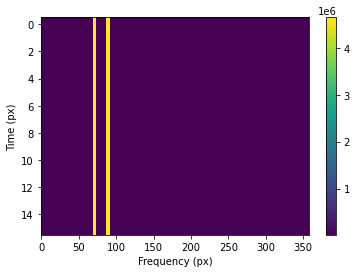

In [71]:
import setigen as stg
from astropy import units as u

c = stg.Frame(fb)
print(c.noise_mean)
print(c.noise_std)
print(c.get_intensity(snr=1000))
# for i in range(10):
#     offset = i*0.0001
#     c.add_signal(stg.constant_path(f_start=((f+offset)*u.MHz),
#                                drift_rate=1*u.Hz/u.s),
#                            stg.constant_t_profile(level=c.get_intensity(snr=1000)),
#                            stg.box_f_profile(width=1*c.df*u.Hz),
#                            stg.constant_bp_profile(level=1),
#                            integrate_f_profile=False,
#                            doppler_smearing=True,
#                            smearing_subsamples=15)
f = 1105.0002
d = 0
dsign = np.sign(d)
print(dsign)
tsamp = 18.253611007999982
print(np.min(((f-dsign*0.0001), (f+d*(1e-6)*tsamp*16+dsign*0.0001))))
print(np.max(((f-dsign*0.0001), (f+d*(1e-6)*tsamp*16+dsign*0.0001))))
c.add_signal(stg.constant_path(f_start=((1105.0002)*u.MHz),
                               drift_rate=(0*u.Hz/u.s)),
                           stg.constant_t_profile(level=c.get_intensity(snr=10000)),
                           stg.box_f_profile(width=3*c.df*u.Hz),
                           stg.constant_bp_profile(level=1),
                           #integrate_path=True,
                           #integrate_f_profile=True,
                           #integrate_t_profile=True,
                           doppler_smearing=True,
                           smearing_subsamples=15)
f = 1105.00025
d = 0.5
dsign = np.sign(d)
print(dsign)
c.add_signal(stg.constant_path(f_start=(f*u.MHz),
                               drift_rate=0*u.Hz/u.s),
                           stg.constant_t_profile(level=c.get_intensity(snr=10000)),
                           stg.box_f_profile(width=5*c.df*u.Hz),
                           stg.constant_bp_profile(level=1),
                           #integrate_path=True,
                           #integrate_f_profile=True,
                           #integrate_t_profile=True,
                           doppler_smearing=True,
                           smearing_subsamples=15)
# f = 1105.0003
# d = 0.5
# dsign = np.sign(d)
# print(dsign)
# c.add_signal(stg.constant_path(f_start=(f*u.MHz),
#                                drift_rate=d*u.Hz/u.s),
#                            stg.constant_t_profile(level=c.get_intensity(snr=10000)),
#                            stg.box_f_profile(width=1*c.df*u.Hz),
#                            stg.constant_bp_profile(level=1),
#                            integrate_path=True,
#                            integrate_f_profile=True,
#                            integrate_t_profile=True,
#                            doppler_smearing=True,
#                            smearing_subsamples=15,
#                            bounding_f_range=(np.min(((f-dsign*0.0001), (f+d*(1e-6)*tsamp*16+dsign*0.0001)))*u.MHz,
#                                             np.max(((f-dsign*0.0001), (f+d*(1e-6)*tsamp*16+dsign*0.0001)))*u.MHz))
# c.add_signal(stg.constant_path(f_start=((f+0.0005)*u.MHz),
#                                drift_rate=0*u.Hz/u.s),
#                            stg.constant_t_profile(level=c.get_intensity(snr=1000)),
#                            stg.box_f_profile(width=1*c.df*u.Hz),
#                            stg.constant_bp_profile(level=1),
#                            integrate_f_profile=False,
#                            doppler_smearing=True,
#                            smearing_subsamples=15)

c.plot(use_db=False)

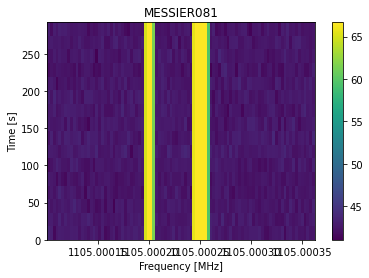

In [68]:
fb.plot_waterfall(f_start=1105.0001, f_stop=1105.00036)

1
2
3
4.0
5
6
7
[0.026666666666666672, 0.29999999999999993, 0.6333333333333333, 0.9133333333333333, 0.6999999999999998, 0.4266666666666664, 0.08666666666666664]
1
2
3.0
4
5.0
6
7
[0.020000000000000004, 0.22499999999999998, 0.45499999999999996, 0.5, 0.48, 0.31999999999999984, 0.06499999999999999]
1
2.0
3
4
5
6.0
7
[0.016000000000000004, 0.164, 0.19999999999999996, 0.19999999999999996, 0.19999999999999996, 0.18399999999999997, 0.05199999999999999]


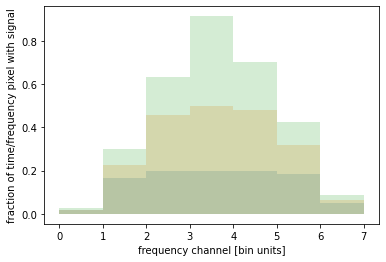

In [35]:
def smeared_bins(p, w, n):
    c = np.ceil(p+w+n) # num columns
    fracvec = []
    # do left triangles
    for i in range(1, int(np.min((np.ceil(p+n), np.ceil(p+w))))):
        print(i)
        frac = 1/(2*n)*((i-p)**2-np.sign(i-1)*(i-1-p)**2)
        fracvec.append(frac)
    # do w ~ n case: left+right quadrilaterals (hexagon) in single freq channel
    if np.ceil(p+n) == np.ceil(p+w):
        i = np.ceil(p+n)
        print(i)
        frac = 1 - 1/(2*n)*((p+n)%1)**2 - 1/(2*n)*(1-(p+w)%1)**2
        fracvec.append(frac)
    # do w << n case (high drift):
    elif np.ceil(p+n) > np.ceil(p+w):
        # do left pentagon
        i = np.ceil(p+w)
        print(i)
        frac = 1/(2*n)*((i-p)**2-(i-1-p)**2-(1-(p+w)%1)**2)
        fracvec.append(frac)
        # do central parallelograms
        num_par = np.ceil(p+n) - np.ceil(p+w)
        a_up = 1/(2*n)
        a_down = 1/(2*n)*((num_par+(n-w)%1)**2 - (num_par-1-(n-w)%1)**2)
        for i in range(int(np.ceil(p+w))+1, int(np.ceil(p+n))):
            print(i)
            frac = 1 - a_up - a_down
            fracvec.append(frac)
        # do right pentagon
        i = np.ceil(p+n)
        print(i)
        frac = 1/(2*n)*(((c-i)+(p+w+n)%1)**2 - ((c-i-1)+(p+w+n)%1)**2 - ((p+n)%1)**2)
        fracvec.append(frac)
    # do w >> n case (low drift):
    else:
        # do left pentagon
        i = np.ceil(p+n)
        print(i)
        frac = 1 - 1/(2*n)*((p+n)%1)**2
        fracvec.append(frac)
        # do central rectangle(s)
        if np.abs(n-w) - np.round(p) >= 1:
            for i in range(int(np.ceil(p+n))+1, int(np.ceil(p+w))+1):
                print(i)
                frac = 1
                fracvec.append(frac)
        # do right pentagon
        i = np.ceil(p+w)
        print(i)
        frac = 1 - 1/(2*n)*(1-(p+w)%1)**2
        fracvec.append(frac)
    # do right triangles
    for i in range(int(np.max((np.ceil(p+w)+1, np.ceil(p+n)+1))), int(c)+1):
        print(i)
        frac = 1/(2*n)*(((c-i)+(p+w+n)%1)**2 - np.sign(c-i-1)*((c-i-1)+(p+w+n)%1)**2)
        fracvec.append(frac)
    return fracvec

fracs3 = smeared_bins(p=0.6, w=3, n=3)
print(fracs3)
fracs2 = smeared_bins(p=0.6, w=2, n=4)
print(fracs2)
fracs1 = smeared_bins(p=0.6, w=1, n=5)
print(fracs1)
plt.fill_between(np.arange(len(fracs1)+1), np.concatenate((fracs1, [0])), step='post', alpha=0.2, lw=2)
plt.fill_between(np.arange(len(fracs2)+1), np.concatenate((fracs2, [0])), step='post', alpha=0.2, lw=2)
plt.fill_between(np.arange(len(fracs3)+1), np.concatenate((fracs3, [0])), step='post', alpha=0.2, lw=2)
plt.xlabel('frequency channel [bin units]')
plt.ylabel('fraction of time/frequency pixel with signal')
plt.show()

1
2
3
4.0
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26.0
27
28
29
[0.0032000000000000006, 0.036, 0.076, 0.11279999999999998, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.1168, 0.08400000000000006, 0.05120000000000009, 0.010400000000000012]
1
2
3.0
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27.0
28
29
[0.003076923076923078, 0.03461538461538462, 0.06999999999999999, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07692307692307687, 0.07384615384615387, 0.04923076

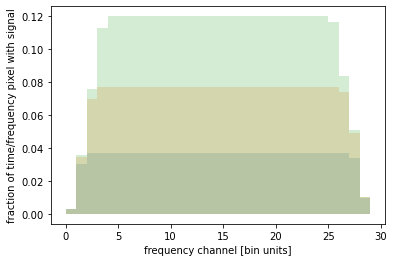

In [49]:
fracs3 = smeared_bins(p=0.6, w=3, n=25)
print(fracs3)
fracs2 = smeared_bins(p=0.6, w=2, n=26)
print(fracs2)
fracs1 = smeared_bins(p=0.6, w=1, n=27)
print(fracs1)
plt.fill_between(np.arange(len(fracs1)+1), np.concatenate((fracs1, [0])), step='post', alpha=0.2, lw=2)
plt.fill_between(np.arange(len(fracs2)+1), np.concatenate((fracs2, [0])), step='post', alpha=0.2, lw=2)
plt.fill_between(np.arange(len(fracs3)+1), np.concatenate((fracs3, [0])), step='post', alpha=0.2, lw=2)
plt.xlabel('frequency channel [bin units]')
plt.ylabel('fraction of time/frequency pixel with signal')
plt.show()

In [10]:
print(np.ceil(0.2+3.4))

4.0


In [9]:
freqs = np.array([f + i*0.00002 for i in range(50)])
print(freqs)

foff = fb.header['foff']
print(foff)

f1 = 0.00001345
print(foff/f1)
print(f1/foff)

[1105.      1105.00002 1105.00004 1105.00006 1105.00008 1105.0001
 1105.00012 1105.00014 1105.00016 1105.00018 1105.0002  1105.00022
 1105.00024 1105.00026 1105.00028 1105.0003  1105.00032 1105.00034
 1105.00036 1105.00038 1105.0004  1105.00042 1105.00044 1105.00046
 1105.00048 1105.0005  1105.00052 1105.00054 1105.00056 1105.00058
 1105.0006  1105.00062 1105.00064 1105.00066 1105.00068 1105.0007
 1105.00072 1105.00074 1105.00076 1105.00078 1105.0008  1105.00082
 1105.00084 1105.00086 1105.00088 1105.0009  1105.00092 1105.00094
 1105.00096 1105.00098]
-2.7939677238464355e-06
-0.2077299422934153
-4.813942510933333


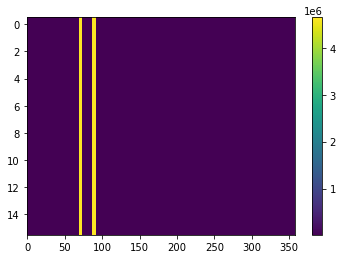

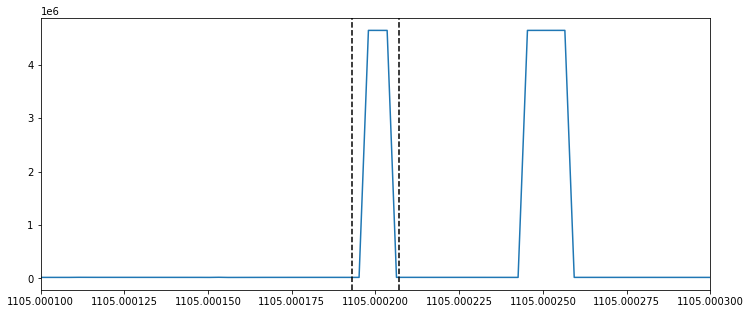

In [72]:
plt.imshow(c.data, aspect='auto', interpolation='none')
plt.colorbar()
plt.show()
x = np.arange(len(c.data[0]))
fig, ax = plt.subplots(figsize=(12,5))
plt.plot(fb.grab_data()[0][::-1], np.mean(c.data,axis=0))
#plt.axhline(462693, color='k')
#plt.axhline(462693+18333.816, color='r')
plt.xlim(1105.0001,1105.0003)
plt.axvline(1105.0002-2.5*fb.header['foff'], color='k', ls='--')
plt.axvline(1105.0002+2.5*fb.header['foff'], color='k', ls='--')
#plt.plot(x, 1000*np.sin(2*np.pi*1/0.00001345*x)+np.mean(fb.data))
#plt.plot(np.arange(len(np.mean(c.data,axis=0))), 2e5*np.sin(2*np.pi*x/len(x)*len(x)/55+(f-0.00018)/foff+np.pi)+250000)
plt.show()

In [173]:
fvec, ims = fb.grab_data()

In [174]:
print(freqs)
print(fvec)

[1105.      1105.00002 1105.00004 1105.00006 1105.00008 1105.0001
 1105.00012 1105.00014 1105.00016 1105.00018 1105.0002  1105.00022
 1105.00024 1105.00026 1105.00028 1105.0003  1105.00032 1105.00034
 1105.00036 1105.00038 1105.0004  1105.00042 1105.00044 1105.00046
 1105.00048 1105.0005  1105.00052 1105.00054 1105.00056 1105.00058
 1105.0006  1105.00062 1105.00064 1105.00066 1105.00068 1105.0007
 1105.00072 1105.00074 1105.00076 1105.00078 1105.0008  1105.00082
 1105.00084 1105.00086 1105.00088 1105.0009  1105.00092 1105.00094
 1105.00096 1105.00098]
[1105.00099976 1105.00099696 1105.00099417 1105.00099137 1105.00098858
 1105.00098579 1105.00098299 1105.0009802  1105.0009774  1105.00097461
 1105.00097182 1105.00096902 1105.00096623 1105.00096343 1105.00096064
 1105.00095785 1105.00095505 1105.00095226 1105.00094946 1105.00094667
 1105.00094388 1105.00094108 1105.00093829 1105.00093549 1105.0009327
 1105.00092991 1105.00092711 1105.00092432 1105.00092153 1105.00091873
 1105.00091594 11

In [175]:
snrs = []
for f in freqs[8:]:
    #print(f)
    ii = np.argmin(np.abs(fvec[::-1]-f))
    window = np.mean(c.data,axis=0)[ii-5:ii+5]
    #snr = np.sum(window-18333.816)/1850.7721
    snr = np.sum(window-18333.816)/1850.7721
    snrs.append(snr)
    #break
#plt.step(np.arange(len(window)), window-18333.816)
#plt.show()
print(window-18333.816)
print(snrs)

[ 4.6407031e+02 -3.2157031e+02  8.4960156e+02  1.5873242e+02
  2.3204186e+05  2.3117427e+05 -3.8442383e+02  2.4883594e+02
 -4.3227930e+02  9.6177734e+02]
[248.8730581685341, 250.72439699625903, 251.23100988500963, 251.1181178114799, 249.04092729731556, 249.98516159823245, 249.84520311820134, 249.23518743879922, 249.05652889407617, 250.64824634540363, 250.93066226252276, 249.11657140282156, 248.26155662277384, 251.69595097635198, 250.86734409385144, 251.0005992904259, 249.7214372045051, 250.24908861009956, 251.06081064762108, 251.47778189437804, 250.44304482437357, 250.202857904547, 250.13874614816163, 250.96070040174047, 249.48493118088393, 249.19620033174263, 249.95152698703424, 249.426914853536, 250.47017877025488, 249.66458593146072, 249.35017323310635, 248.41448266374883, 249.59323057657937, 249.8832277890941, 250.4057462018149, 248.97806501945865, 249.58254246970765, 251.48944932225854, 250.28540791164943, 249.82946644268088, 249.74237441227908, 251.1172904540759]


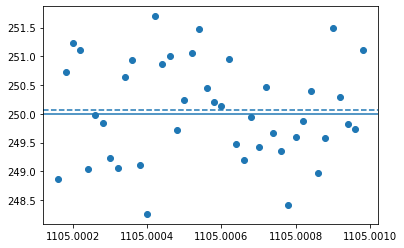

In [176]:
plt.scatter(freqs[8:], snrs)
plt.axhline(1000/np.sqrt(fb.data.shape[0]))
plt.axhline(np.average(snrs), ls='--')
plt.show()

In [2]:
fbv = bl.Waterfall('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_low_drift_every_2_kHz.h5')
power_vals = fbv.data

In [3]:
print(power_vals.shape)

(16, 1, 1048576)


In [3]:
center_frequencies = np.arange(8418.457034043968+0.002, 8421.38671875-0.002, 0.002)

extracting integration 0...


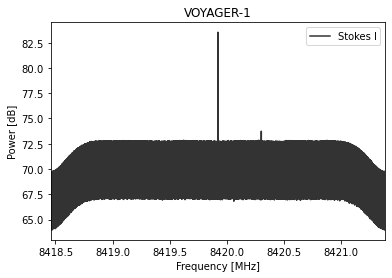

In [5]:
i = 50
#fbv.plot_spectrum(logged=True, f_start=center_frequencies[i]-0.009, f_stop=center_frequencies[i]+0.009)
fbv.plot_spectrum(logged=True)

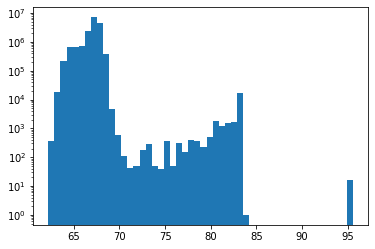

In [6]:
plt.hist(10*np.log10(power_vals.flatten()), bins=50)
plt.yscale('log')
plt.show()

In [4]:
from astropy.stats import sigma_clip
idxs = np.argsort(power_vals.flatten())
icut = idxs[int(0.05*len(idxs)):int(0.95*len(idxs))]
med_power_vals_sorted = power_vals.flatten()[icut]
noise = np.std(med_power_vals_sorted)
noise_floor = np.mean(med_power_vals_sorted)
clip_power_vals = sigma_clip(power_vals,
                                  sigma=3,
                                  maxiters=5,
                                  masked=False)
sig_noise = np.std(clip_power_vals)
sig_noise_floor = np.std(clip_power_vals)

In [9]:
print(noise_floor)
print(sig_noise_floor)

5187746.5
859039.25


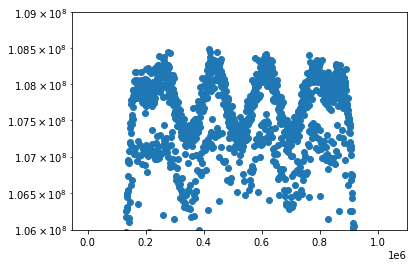

In [29]:
plt.plot(np.average(np.squeeze(power_vals),axis=0), marker='o', lw=0)
plt.yscale('log')
#plt.xlim(100000, 100000+2000)
plt.ylim(1.06e8, 1.09e8)
plt.axhline(noise_floor, color='k', ls='--')
plt.show()

In [10]:
fvec, ims = fbv.grab_data()

In [5]:
tseti_file = '/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_low_drift_every_2_kHz.10_seticore.dat'
dft = pd.read_table(tseti_file, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
tseti_freqs = dft['Uncorrected_Frequency'].values
tseti_snrs = dft['SNR'].values

bliss_file = '/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_low_drift_every_2_kHz_SNR_30_L1_10.dat'
dfb = pd.read_table(bliss_file, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
bliss_freqs = dfb['Uncorrected_Frequency'].values
bliss_snrs = dfb['SNR'].values

test_tseti_file = '/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_test.10_seticore.dat'
test_tseti_file = '/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_many_widths_many_drifts.10_seticore.dat'
dft_test = pd.read_table(test_tseti_file, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
tseti_test_freqs = dft_test['Uncorrected_Frequency'].values
tseti_test_snrs = dft_test['SNR'].values

test_bliss_file = '/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_test_SNR_30_L1_10.dat'
test_bliss_file = '/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_many_widths_many_drifts_SNR_30_L1_10.dat'
dfb_test = pd.read_table(test_bliss_file, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
bliss_test_freqs = dfb_test['Uncorrected_Frequency'].values
bliss_test_snrs = dfb_test['SNR'].values

In [12]:
snrs = []
for n, f0 in enumerate(center_frequencies):
    #print(f0)
    ii = np.argmin(np.abs(fvec[::-1]-f0))
    window = np.average(np.squeeze(power_vals),axis=0)[ii-8:ii+8]
    snr = np.max(window)/sig_noise
    snrs.append(snr)
    #plt.step(np.arange(len(window)), window)
    #plt.show()
    #if n > 5:
    #    break
print(snrs)

[62.085854, 62.593784, 62.615578, 62.457127, 62.793167, 62.30368, 62.81098, 63.046303, 62.98259, 63.333138, 62.674458, 63.12424, 63.37144, 63.370953, 63.690598, 63.374596, 63.98422, 64.36092, 64.29477, 63.983356, 63.995213, 64.905815, 65.07149, 65.2915, 65.075874, 65.80953, 66.03785, 66.45053, 66.52735, 66.36361, 67.17998, 67.52289, 67.702324, 68.0982, 67.64564, 68.7158, 69.0417, 69.49792, 69.692245, 69.41099, 70.28348, 70.573135, 71.14105, 71.535675, 71.190834, 72.26631, 72.60004, 72.97807, 72.829185, 73.17115, 74.3696, 74.73943, 75.07469, 74.88786, 76.053734, 76.5503, 76.900055, 77.40193, 77.25332, 78.371574, 78.79954, 79.243935, 79.692825, 79.411316, 80.49318, 81.06511, 81.61008, 82.09077, 81.86525, 82.90492, 83.510025, 83.99567, 84.534996, 84.39173, 85.6127, 86.08649, 86.419975, 86.93916, 86.88295, 88.038055, 88.356705, 88.8441, 88.623436, 89.86334, 90.43064, 91.03639, 91.22662, 91.059814, 92.4007, 93.25705, 93.344826, 93.95285, 93.65345, 94.89114, 95.42352, 95.88478, 96.35646, 96.

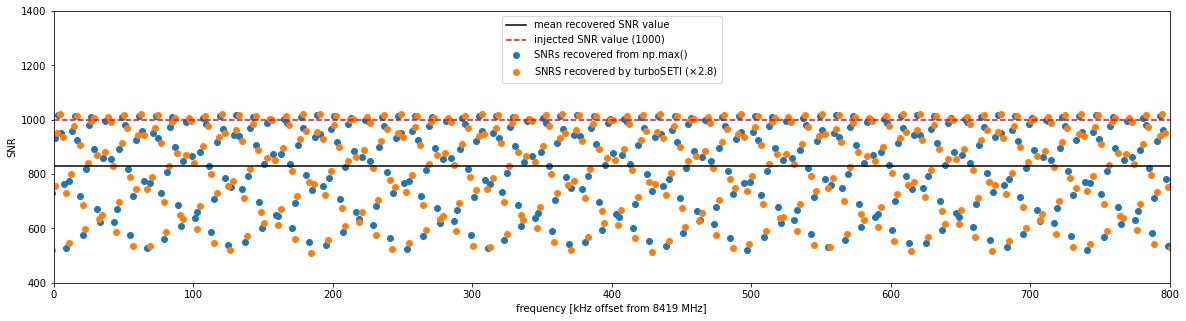

In [42]:
fig, ax = plt.subplots(figsize=(20,5))
plt.scatter((center_frequencies-8419)*1000, np.array(snrs)*4, label='SNRs recovered from np.max()')
plt.scatter((tseti_freqs-8419)*1000, tseti_snrs*2.8, label=r'SNRS recovered by turboSETI ($\times2.8$)')
plt.axhline(np.mean(snrs)*4, color='k', label='mean recovered SNR value')
plt.axhline(1000, color='r', ls='--', label='injected SNR value (1000)')

# vline = 62
# plt.axvline(vline)
# plt.axvline(vline*2)
# plt.axvline(vline*3)
# plt.axvline(vline*4)
# plt.axvline(vline*5)
# plt.axvline(vline*6)
# plt.axvline(vline*7)
# plt.axvline(vline*8)
#plt.axvline(-0.002/foff)

plt.xlim(0, 800)
plt.ylim(400, 1400)
plt.xlabel('frequency [kHz offset from 8419 MHz]')
plt.ylabel('SNR')
plt.legend(loc='upper center')
plt.show()

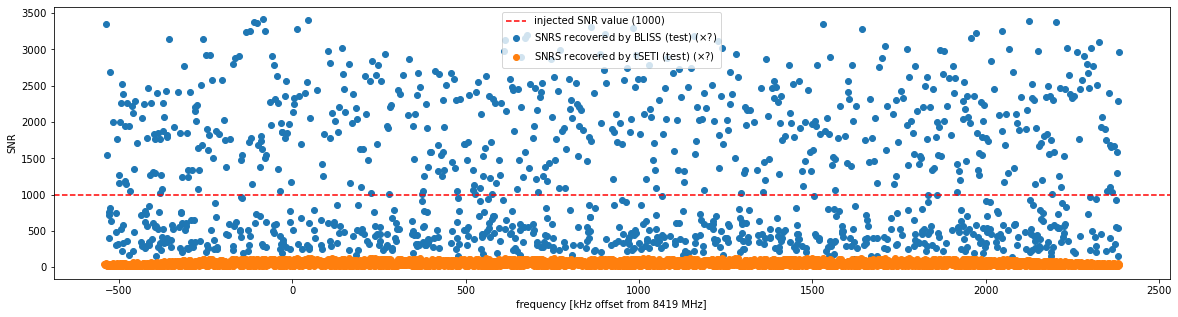

In [8]:
fig, ax = plt.subplots(figsize=(20,5))
#plt.scatter((center_frequencies-8419)*1000, np.array(snrs)*4*2, label='SNRs recovered from np.max()')
#plt.scatter((tseti_freqs-8419)*1000, tseti_snrs*3.3, label=r'SNRS recovered by turboSETI ($\times3.3$)')
#plt.scatter((bliss_freqs-8419)*1000, bliss_snrs*0.79, label=r'SNRS recovered by BLISS ($\times$?)')
plt.scatter((bliss_test_freqs-8419)*1000, bliss_test_snrs, label=r'SNRS recovered by BLISS (test) ($\times$?)')
plt.scatter((tseti_test_freqs-8419)*1000, tseti_test_snrs, label=r'SNRS recovered by tSETI (test) ($\times$?)')
plt.axhline(1000, color='r', ls='--', label='injected SNR value (1000)')

# vline = 62
# plt.axvline(vline)
# plt.axvline(vline*2)
# plt.axvline(vline*3)
# plt.axvline(vline*4)
# plt.axvline(vline*5)
# plt.axvline(vline*6)
# plt.axvline(vline*7)
# plt.axvline(vline*8)
#plt.axvline(-0.002/foff)

#plt.xlim(0, 500)
#plt.ylim(0, 2000)
plt.xlabel('frequency [kHz offset from 8419 MHz]')
plt.ylabel('SNR')
plt.legend(loc='upper center')
plt.show()

In [21]:
500/8

62.5

In [ ]:
0.002/foff

-715.8278826666667